# ✈️ NASA C-MAPSS FD003 — 딥러닝: BiLSTM

| 항목 | 내용 |
|------|------|
| 데이터셋 | **FD003** — HPC 열화 + Fan 열화 (2가지 고장 모드) |
| 운전 조건 | **1가지** (Sea Level 단일 조건) |
| 모델 | **BiLSTM** — 양방향 BiLSTM — 순방향+역방향 동시 학습으로 열화 패턴 포착 |
| 전처리 | MJ 전처리 노트북 (No-Clustering, cap=125, σ=2, win=30) |
| 평가 지표 | RMSE · NASA Score · MAE · R² |
| 공식 평가 | 엔진당 **마지막 윈도우** (is_last=True) 기준 |

> **FD001 대비 FD003 특이사항**
> - 고장 모드 2개 (HPC + Fan 열화) → 센서 패턴이 혼재되어 난이도 높음
> - 운전 조건은 동일(1개)이므로 정규화 방식은 Global MinMax 유지
> - 테스트 CSV에 `is_last` 플래그 포함 → 공식 평가 시 필터링 적용


## 0. 환경 초기화 — 반드시 첫 번째 셀로 실행

In [2]:
# ⚠️ 독립 실험 보장: GPU 메모리 및 전역 상태 초기화
import gc, torch, numpy as np, random

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print('✅ 환경 초기화 완료')
print(f'   모델     : BiLSTM')
print(f'   데이터셋 : FD003')
print(f'   CUDA 사용: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


✅ 환경 초기화 완료
   모델     : BiLSTM
   데이터셋 : FD003
   CUDA 사용: True
   GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
   VRAM: 102.0 GB


## 1. 라이브러리 설치 및 임포트

In [3]:
import sys, subprocess
REQUIRED = ['torch','numpy','pandas','scikit-learn','matplotlib',
            'seaborn','joblib','optuna','mlflow']
for pkg in REQUIRED:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('✅ 패키지 확인 완료')


✅ 패키지 확인 완료


In [4]:
import os, warnings, time, json, math, platform
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, optuna, mlflow, mlflow.pytorch
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import logging
import matplotlib.font_manager as fm
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

def force_korean_font():
    system = platform.system()
    if system == "Windows":
        font_path = r"C:\Windows\Fonts\malgun.ttf"
        font_name = "Malgun Gothic"
    elif system == "Darwin":
        font_path = "/System/Library/Fonts/AppleGothic.ttf"
        font_name = "AppleGothic"
    else:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        font_name = "NanumGothic"
        if not os.path.exists(font_path):
            os.system("apt-get update -qq")
            os.system("apt-get install -y fonts-nanum -qq")
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 한글 폰트 적용: {font_name}")
    else:
        print("❌ 폰트 못 찾음")

force_korean_font()

BG,BG2,GRID='#0f1117','#1a1d2e','#2d3148'
WHITE,GRAY='#ffffff','#aaaaaa'
C=['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']
MODEL_COLOR = '#51cf66'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG2,'axes.edgecolor':GRID,
    'axes.labelcolor':GRAY,'xtick.color':GRAY,'ytick.color':GRAY,'text.color':WHITE,
    'grid.color':GRID,'grid.alpha':0.4,'axes.grid':True,'font.size':10,
    'legend.facecolor':BG2,'legend.edgecolor':GRID})
force_korean_font()

# ── 전역 상수 ───────────────────────────────────────────────────
# MJ 전처리 기본값: No-Clustering, cap=125, sig=2, win=30
PREPROCESSING_PREFIX = 'FD003_nc_cap125_sig2_win30'  # 전처리 파일명 prefix

DATA_DIR        = 'preprocessed_FD003'
DL_DIR          = 'preprocessed_FD003/dl'
RESULT_DIR      = 'results_dl_fd003_bilstm'
MODEL_DIR       = 'models_dl_fd003_bilstm'
MLFLOW_DIR      = 'mlruns'
EXPERIMENT_NAME = 'CMAPSS_FD003_DL_BiLSTM'
DATASET_NAME    = 'FD003'
MODEL_NAME_STR  = 'BiLSTM'

RANDOM_STATE  = 42
WINDOW_SIZE   = 30
CLIP_LOWER    = 0.0
BATCH_SIZE    = 256
N_TRIALS      = 30
EPOCHS_SEARCH = 50
EPOCHS_FINAL  = 100
PATIENCE      = 10
USE_ADAMW     = True
OPTIMIZER_NAME= 'AdamW'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

print('✅ 설정 완료')
print(f'   Dataset={DATASET_NAME}  Model={MODEL_NAME_STR}')
print(f'   Device={DEVICE}  Optimizer={OPTIMIZER_NAME}')
print(f'   N_TRIALS={N_TRIALS}  EPOCHS_FINAL={EPOCHS_FINAL}')
print(f'   Preprocessing prefix: {PREPROCESSING_PREFIX}')


✅ 한글 폰트 적용: NanumGothic
✅ 한글 폰트 적용: NanumGothic
✅ 설정 완료
   Dataset=FD003  Model=BiLSTM
   Device=cuda  Optimizer=AdamW
   N_TRIALS=30  EPOCHS_FINAL=100
   Preprocessing prefix: FD003_nc_cap125_sig2_win30


## 2. 데이터 로드

=== 2. 데이터 로드 ===
DL 피처 (15개): ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
X_sub  : (17692, 30, 15)  y_sub  : (17692,)
X_val  : (4128, 30, 15)  y_val  : (4128,)
X_test : (100, 30, 15)  (전체 윈도우)
X_test_last: (100, 30, 15)  (엔진당 마지막 — 공식 평가)
✅ val_eval 로드: (20, 30, 15)  RUL: 16~114


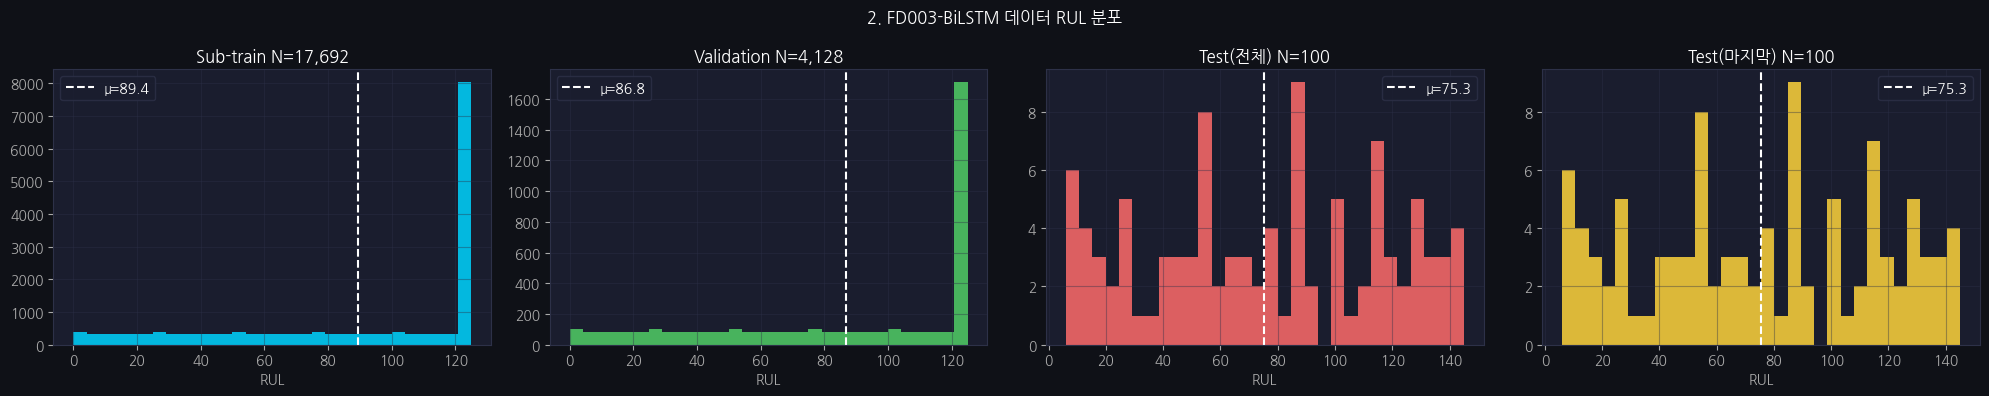

✅ 데이터 로드 완료


In [5]:
print('=== 2. 데이터 로드 ===')

# ── 피처 목록 로드 ──────────────────────────────────────────────
# MJ 전처리: FD003_nc_dl_features.txt (USEFUL_SENSORS 기준)
dl_feat_path = os.path.join(DATA_DIR, f'{PREPROCESSING_PREFIX}_dl_features.txt')
# fallback: 구버전 경로
if not os.path.exists(dl_feat_path):
    dl_feat_path = os.path.join(DATA_DIR, 'FD003_nc_dl_features.txt')
with open(dl_feat_path, 'r', encoding='utf-8') as f:
    DL_FEATURES = [l.strip() for l in f if l.strip()]
N_FEATURES = len(DL_FEATURES)
print(f'DL 피처 ({N_FEATURES}개): {DL_FEATURES}')


def load_long_format(path, feature_cols, last_only=False):
    """Long Format CSV → (X, y) numpy 배열

    Parameters
    ----------
    last_only : bool
        True  → is_last==True 인 샘플만 추출 (공식 평가용, 엔진당 1샘플)
        False → 전체 윈도우 (학습/early stopping용)
    """
    df = pd.read_csv(path)
    if last_only and 'is_last' in df.columns:
        last_ids = df[df['is_last'] == True]['sample_id'].unique()
        df = df[df['sample_id'].isin(last_ids)]
    df = df.sort_values(['sample_id', 'timestep']).reset_index(drop=True)
    n_samples   = df['sample_id'].nunique()
    window_size = int(df['timestep'].max()) + 1
    feats       = [c for c in feature_cols if c in df.columns]
    X = df[feats].values.reshape(n_samples, window_size, len(feats)).astype(np.float32)
    y = df.groupby('sample_id', sort=False)['RUL'].last().values.astype(np.float32)
    return X, y


# ── 학습/검증 데이터 (전체 슬라이딩 윈도우) ─────────────────────
X_sub,  y_sub  = load_long_format(
    os.path.join(DL_DIR, f'{PREPROCESSING_PREFIX}_dl_subtrain_long.csv'), DL_FEATURES)
X_val,  y_val  = load_long_format(
    os.path.join(DL_DIR, f'{PREPROCESSING_PREFIX}_dl_valid_long.csv'),   DL_FEATURES)

# ── 테스트 데이터 ────────────────────────────────────────────────
# X_test      : 전체 윈도우 (RUL 역산 포함) — 분포 확인용
# X_test_last : 엔진당 마지막 윈도우만    — C-MAPSS 공식 평가 기준
test_path = os.path.join(DL_DIR, f'{PREPROCESSING_PREFIX}_dl_test_long.csv')
X_test,      y_test      = load_long_format(test_path, DL_FEATURES, last_only=False)
X_test_last, y_test_last = load_long_format(test_path, DL_FEATURES, last_only=True)

print(f'X_sub  : {X_sub.shape}  y_sub  : {y_sub.shape}')
print(f'X_val  : {X_val.shape}  y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}  (전체 윈도우)')
print(f'X_test_last: {X_test_last.shape}  (엔진당 마지막 — 공식 평가)')

# ── val_eval: 50~90% 절단 평가셋 (테스트 조건 모방) ─────────────
_val_eval_path = os.path.join(DL_DIR, f'{PREPROCESSING_PREFIX}_dl_val_eval_long.csv')
# fallback: 구버전 경로
if not os.path.exists(_val_eval_path):
    _val_eval_path = os.path.join(DL_DIR, 'FD003_nc_dl_val_eval_long.csv')

if os.path.exists(_val_eval_path):
    _df_ve = pd.read_csv(_val_eval_path)
    _df_ve = _df_ve.sort_values(['sample_id','timestep']).reset_index(drop=True)
    _n_ve  = _df_ve['sample_id'].nunique()
    _ws_ve = int(_df_ve['timestep'].max()) + 1
    _feats_ve = [c for c in DL_FEATURES if c in _df_ve.columns]
    X_val_eval = _df_ve[_feats_ve].values.reshape(_n_ve, _ws_ve, len(_feats_ve)).astype(np.float32)
    y_val_eval = _df_ve.groupby('sample_id', sort=False)['RUL'].last().values.astype(np.float32)
    print(f'✅ val_eval 로드: {X_val_eval.shape}  RUL: {y_val_eval.min():.0f}~{y_val_eval.max():.0f}')
else:
    print('⚠️  val_eval CSV 없음 → val 전체로 대체 (전처리 재실행 권장)')
    X_val_eval = X_val.copy()
    y_val_eval = y_val.copy()

# ── RUL 분포 시각화 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(f'2. {DATASET_NAME}-{MODEL_NAME_STR} 데이터 RUL 분포', fontweight='bold')
for ax, (name, y, col) in zip(axes, [
    ('Sub-train',    y_sub,       C[0]),
    ('Validation',   y_val,       C[2]),
    ('Test(전체)',   y_test,      C[1]),
    ('Test(마지막)', y_test_last, C[3]),
]):
    ax.hist(y, bins=30, color=col, alpha=0.85)
    ax.axvline(y.mean(), color='white', ls='--', lw=1.5, label=f'μ={y.mean():.1f}')
    ax.set_title(f'{name} N={len(y):,}')
    ax.set_xlabel('RUL'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ 데이터 로드 완료')


## 3. Dataset / DataLoader / 평가 함수

In [6]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def clip_rul(arr): return np.clip(np.array(arr), a_min=CLIP_LOWER, a_max=None)

def nasa_score(y_true, y_pred):
    """C-MAPSS 공식 비대칭 NASA Score (늦은 예측에 더 큰 패널티)"""
    d = np.array(y_pred) - np.array(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

def predict_np(model, X_np):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), BATCH_SIZE):
            xb = torch.tensor(X_np[i:i+BATCH_SIZE], dtype=torch.float32).to(DEVICE)
            pad_mask = (xb.sum(dim=-1) == 0)
            out = model(xb, src_key_padding_mask=pad_mask).squeeze(-1).cpu().numpy()
            preds.extend(out.tolist())
    return clip_rul(np.array(preds))

def evaluate_loader(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            pad_mask = (xb.sum(dim=-1) == 0)
            p = model(xb, src_key_padding_mask=pad_mask).squeeze(-1).cpu().numpy()
            preds.extend(p.tolist()); targets.extend(yb.numpy().tolist())
    preds   = clip_rul(np.array(preds))
    targets = np.array(targets)
    return float(np.sqrt(np.mean((preds-targets)**2))), nasa_score(targets, preds), preds, targets

def evaluate_val_eval(model):
    """val_eval 기준 NASA Score + RMSE (테스트 조건 모방 평가)"""
    preds = predict_np(model, X_val_eval)
    return nasa_score(y_val_eval, preds), float(np.sqrt(np.mean((preds-y_val_eval)**2)))

def evaluate_test_official(model):
    """공식 평가: 엔진당 마지막 윈도우 (X_test_last) 기준"""
    preds = predict_np(model, X_test_last)
    rmse  = float(np.sqrt(np.mean((preds - y_test_last)**2)))
    ns    = nasa_score(y_test_last, preds)
    return rmse, ns, preds

# DataLoader
train_loader = DataLoader(RULDataset(X_sub,  y_sub),  batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(RULDataset(X_val,  y_val),  batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(RULDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print('✅ Dataset / DataLoader / 평가 함수 정의 완료')
print(f'   train_loader: {len(train_loader.dataset):,}샘플')
print(f'   val_loader  : {len(val_loader.dataset):,}샘플  ← early stopping 기준')
print(f'   test_loader : {len(test_loader.dataset):,}샘플  (전체 윈도우)')
print(f'   공식 평가   : X_test_last {X_test_last.shape}  (엔진당 1샘플)')


✅ Dataset / DataLoader / 평가 함수 정의 완료
   train_loader: 17,692샘플
   val_loader  : 4,128샘플  ← early stopping 기준
   test_loader : 100샘플  (전체 윈도우)
   공식 평가   : X_test_last (100, 30, 15)  (엔진당 1샘플)


## 4. 모델 아키텍처 — BiLSTM

In [7]:
class BiLSTMModel(nn.Module):
    def __init__(self, n_feat, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers>1 else 0,
                            bidirectional=True)
        self.fc      = nn.Linear(hidden_size * 2, 1)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, src_key_padding_mask=None):
        if src_key_padding_mask is not None:
            lengths = (~src_key_padding_mask).sum(dim=1).clamp(min=1).cpu()
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths, batch_first=True, enforce_sorted=False)
            _, (hn, _) = self.lstm(packed)
        else:
            _, (hn, _) = self.lstm(x)
        hn_cat = torch.cat([hn[-2], hn[-1]], dim=-1)
        return self.fc(self.dropout(hn_cat))

MODEL_CLASS = BiLSTMModel
MODEL_NAME  = 'BiLSTM'


In [8]:
# 모델 파라미터 수 확인
sample_model = MODEL_CLASS(n_feat=N_FEATURES)
n_params = sum(p.numel() for p in sample_model.parameters())
print(f'✅ {MODEL_NAME} 모델 정의 완료')
print(f'   기본 설정 파라미터 수: {n_params:,}개')
del sample_model
gc.collect()


✅ BiLSTM 모델 정의 완료
   기본 설정 파라미터 수: 544,001개


159

## 5. 학습 유틸리티 (AdamW)

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pad_mask = (xb.sum(dim=-1) == 0)
        pred = model(xb, src_key_padding_mask=pad_mask).squeeze(-1)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
    return total_loss / len(loader.dataset)

def build_optimizer(model, params):
    lr = params.get('lr', 1e-3)
    wd = params.get('weight_decay', 0.0)
    if USE_ADAMW:
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode='min', factor=0.5, patience=7, min_lr=1e-6)
        return opt, sch
    else:
        opt = optim.Adam(model.parameters(), lr=lr)
        return opt, None

def train_model(params, epochs):
    model = MODEL_CLASS(n_feat=N_FEATURES,
                        **{k:v for k,v in params.items() if k not in ['lr','weight_decay']}).to(DEVICE)
    optimizer, scheduler = build_optimizer(model, params)
    criterion = nn.HuberLoss(delta=10.0)  # RUL 범위[0,125]에 맞게 delta 설정

    best_val_rmse = float('inf')
    best_state    = None
    patience_cnt  = 0

    for epoch in range(1, epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_rmse, val_ns, _, _ = evaluate_loader(model, val_loader)
        if scheduler is not None:
            scheduler.step(val_rmse)
        cur_lr = optimizer.param_groups[0]['lr']

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state    = deepcopy(model.state_dict())
            patience_cnt  = 0
        else:
            patience_cnt += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'    Epoch {epoch:3d} | loss={train_loss:.4f} | val_rmse={val_rmse:.3f} | lr={cur_lr:.2e}')
        if patience_cnt >= PATIENCE:
            print(f'    Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    return model

print(f'✅ 학습 유틸리티 정의 완료')
print(f'   옵티마이저: {OPTIMIZER_NAME}')
print(f'   Scheduler : {"ReduceLROnPlateau" if USE_ADAMW else "없음"}')
print(f'   HuberLoss delta=10.0  (FD003 RUL 범위 [0, 125])')


✅ 학습 유틸리티 정의 완료
   옵티마이저: AdamW
   Scheduler : ReduceLROnPlateau
   HuberLoss delta=10.0  (FD003 RUL 범위 [0, 125])


## 6. Optuna 하이퍼파라미터 탐색

=== 6. Optuna HPO — BiLSTM (30 trials) ===


  0%|          | 0/30 [00:00<?, ?it/s]

    Epoch   1 | loss=769.9089 | val_rmse=83.696 | lr=7.66e-04
    Epoch  10 | loss=322.1560 | val_rmse=41.988 | lr=7.66e-04
    Epoch  20 | loss=115.6919 | val_rmse=18.008 | lr=3.83e-04
    Epoch  30 | loss=82.3539 | val_rmse=14.927 | lr=3.83e-04
    Epoch  40 | loss=68.8986 | val_rmse=14.327 | lr=3.83e-04
    Epoch  50 | loss=63.0259 | val_rmse=13.475 | lr=3.83e-04
    Epoch   1 | loss=806.6530 | val_rmse=88.140 | lr=7.73e-04
    Epoch  10 | loss=414.8788 | val_rmse=48.387 | lr=7.73e-04
    Epoch  20 | loss=238.9974 | val_rmse=29.517 | lr=7.73e-04
    Epoch  30 | loss=181.5619 | val_rmse=24.378 | lr=7.73e-04
    Epoch  40 | loss=140.3394 | val_rmse=20.095 | lr=7.73e-04
    Epoch  50 | loss=107.3731 | val_rmse=18.216 | lr=7.73e-04
    Epoch   1 | loss=840.0902 | val_rmse=94.911 | lr=2.06e-04
    Epoch  10 | loss=713.9731 | val_rmse=83.312 | lr=2.06e-04
    Epoch  20 | loss=630.7517 | val_rmse=74.767 | lr=2.06e-04
    Epoch  30 | loss=558.6429 | val_rmse=66.735 | lr=2.06e-04
    Epoch  

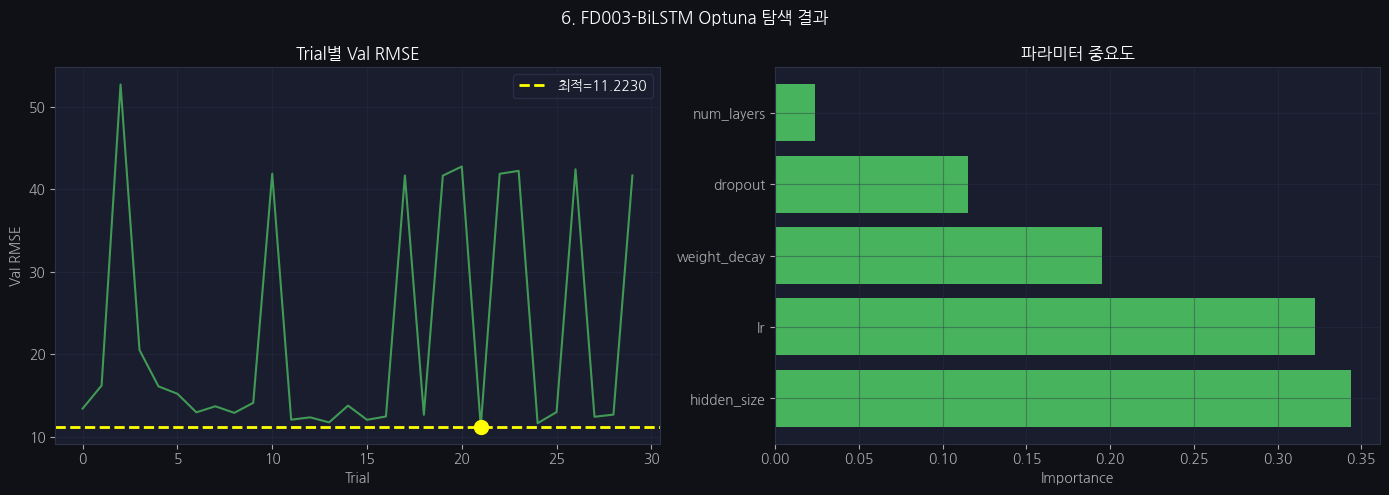

In [10]:
print(f'=== 6. Optuna HPO — {MODEL_NAME_STR} ({N_TRIALS} trials) ===')

def objective(trial):
    params = {
        'hidden_size' : trial.suggest_int('hidden_size',  32, 160),  # BiLSTM: 상한 낮춤 (파라미터 과다 방지)
        'num_layers'  : trial.suggest_int('num_layers',   1,  3),
        'dropout'     : trial.suggest_float('dropout',    0.1, 0.5),
        'lr'          : trial.suggest_float('lr',         1e-4, 3e-3, log=True),
    }
    if USE_ADAMW:
        params['weight_decay'] = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)

    model = train_model(params, EPOCHS_SEARCH)
    # early stopping 기준: validation 전체 RMSE
    val_rmse_full, _, _, _ = evaluate_loader(model, val_loader)
    del model
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return val_rmse_full

study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    study_name=f'{DATASET_NAME}_{MODEL_NAME_STR}'
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'\n✅ Optuna 완료')
print(f'   최적 파라미터: {best_params}')
print(f'   최적 Val RMSE: {study.best_value:.4f}')

# 탐색 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'6. {DATASET_NAME}-{MODEL_NAME_STR} Optuna 탐색 결과', fontweight='bold')

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], color=MODEL_COLOR, lw=1.5, alpha=0.7)
axes[0].axhline(study.best_value, color='yellow', ls='--', lw=2, label=f'최적={study.best_value:.4f}')
axes[0].scatter([study.best_trial.number],[study.best_value], color='yellow', s=100, zorder=5)
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Val RMSE'); axes[0].legend()
axes[0].set_title('Trial별 Val RMSE')

try:
    importance = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importance.keys()), list(importance.values()), color=MODEL_COLOR, alpha=0.85)
    axes[1].set_title('파라미터 중요도'); axes[1].set_xlabel('Importance')
except Exception as e:
    axes[1].text(0.3, 0.5, f'중요도 계산 불가\n{e}', transform=axes[1].transAxes)
plt.tight_layout(); plt.show()


## 7. 최적 파라미터로 최종 학습

In [11]:
print(f'=== 7. 최종 학습 (epochs={EPOCHS_FINAL}) ===')
print(f'   파라미터: {best_params}')

mlflow.set_experiment(EXPERIMENT_NAME)

t0 = time.time()
with mlflow.start_run(run_name=f'{DATASET_NAME}_{MODEL_NAME_STR}_final'):
    BEST_MODEL = train_model(best_params, EPOCHS_FINAL)
    fit_time   = time.time() - t0
    n_params   = sum(p.numel() for p in BEST_MODEL.parameters())

    # ── 평가 ─────────────────────────────────────────────────────
    val_nasa_eval, val_rmse_eval = evaluate_val_eval(BEST_MODEL)          # val_eval 기준
    test_rmse_off, test_nasa_off, test_preds_off = evaluate_test_official(BEST_MODEL)  # 공식(마지막)
    _, _, test_preds_all, test_targets_all = evaluate_loader(BEST_MODEL, test_loader)  # 전체
    val_rmse_full, val_ns_full, _, _ = evaluate_loader(BEST_MODEL, val_loader)

    # 최종 평가 기준: X_test_last (공식)
    test_preds   = test_preds_off
    test_targets = y_test_last

    # MLflow 기록
    mlflow.log_params({
        **best_params,
        'model'          : MODEL_NAME_STR,
        'dataset'        : DATASET_NAME,
        'optimizer'      : OPTIMIZER_NAME,
        'scheduler'      : 'ReduceLROnPlateau' if USE_ADAMW else 'None',
        'window_size'    : WINDOW_SIZE,
        'n_features'     : N_FEATURES,
        'n_trials'       : N_TRIALS,
        'epochs_final'   : EPOCHS_FINAL,
        'n_params'       : n_params,
        'preprocessing'  : PREPROCESSING_PREFIX,
    })
    mlflow.log_metrics({
        'val_nasa_eval'  : val_nasa_eval,
        'val_rmse_eval'  : val_rmse_eval,
        'val_rmse_full'  : val_rmse_full,
        'test_rmse_off'  : test_rmse_off,
        'test_nasa_off'  : test_nasa_off,
        'test_mae'       : mean_absolute_error(test_targets, test_preds),
        'test_r2'        : r2_score(test_targets, test_preds),
        'fit_seconds'    : fit_time,
    })
    mlflow.pytorch.log_model(BEST_MODEL, MODEL_NAME_STR)

print(f'\n✅ 최종 학습 완료 ({fit_time:.1f}초)')
print(f'   파라미터 수          : {n_params:,}')
print(f'   Val NASA(eval)       : {val_nasa_eval:.2f}')
print(f'   Val RMSE(eval)       : {val_rmse_eval:.3f}')
print(f'   Test RMSE [공식]     : {test_rmse_off:.3f}  ← 엔진당 마지막 윈도우 기준')
print(f'   Test NASA [공식]     : {test_nasa_off:.2f}')


=== 7. 최종 학습 (epochs=100) ===
   파라미터: {'hidden_size': 99, 'num_layers': 2, 'dropout': 0.159485507210749, 'lr': 0.002803805018707268, 'weight_decay': 0.00901433674615103}


2026/04/30 06:42:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/30 06:42:45 INFO mlflow.store.db.utils: Updating database tables
2026/04/30 06:42:46 INFO mlflow.tracking.fluent: Experiment with name 'CMAPSS_FD003_DL_BiLSTM' does not exist. Creating a new experiment.


    Epoch   1 | loss=648.3531 | val_rmse=60.319 | lr=2.80e-03
    Epoch  10 | loss=115.9357 | val_rmse=21.138 | lr=2.80e-03
    Epoch  20 | loss=62.8512 | val_rmse=13.574 | lr=2.80e-03
    Epoch  30 | loss=53.9904 | val_rmse=13.118 | lr=2.80e-03


2026/04/30 06:42:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 06:42:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/30 06:42:59 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


    Early stopping at epoch 37


2026/04/30 06:43:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



✅ 최종 학습 완료 (12.7초)
   파라미터 수          : 328,879
   Val NASA(eval)       : 43.98
   Val RMSE(eval)       : 11.731
   Test RMSE [공식]     : 18.227  ← 엔진당 마지막 윈도우 기준
   Test NASA [공식]     : 1451.92


## 8. 결과 시각화

=== 8. 결과 시각화 ===


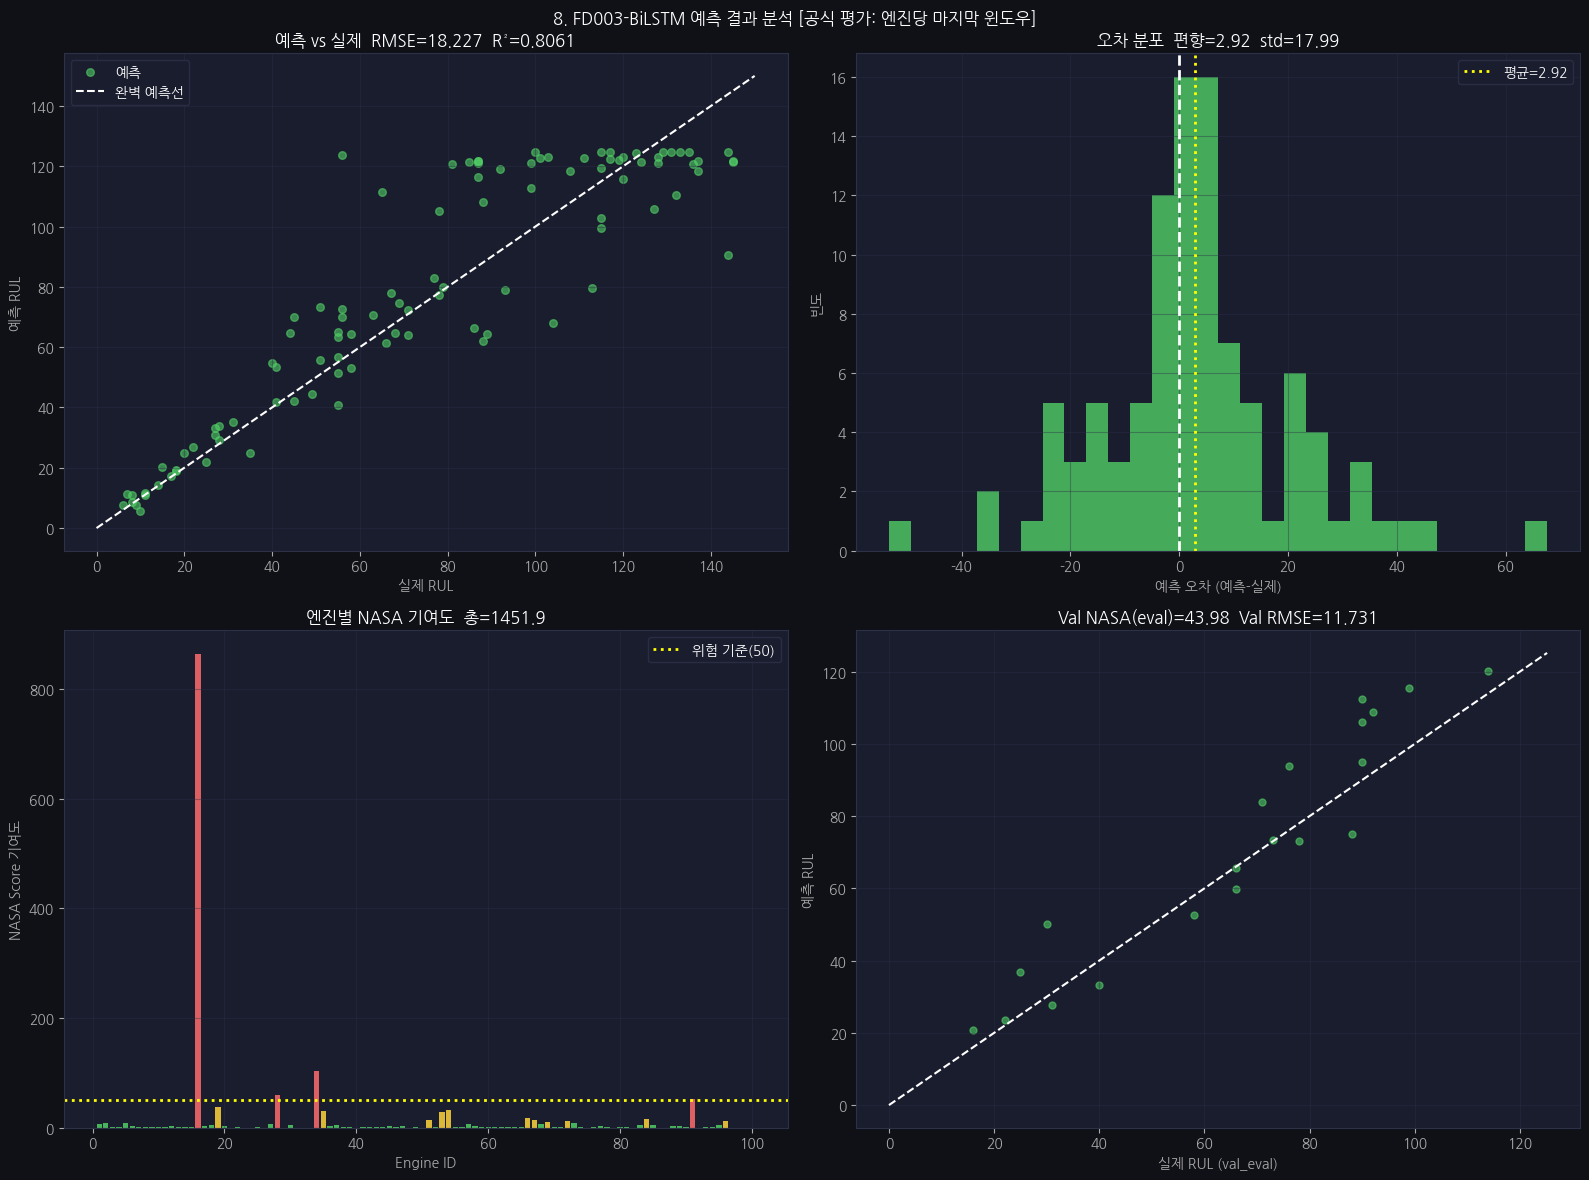

📊 결과 저장: results_dl_fd003_bilstm/FD003_BiLSTM_result.png


In [12]:
print('=== 8. 결과 시각화 ===')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'8. {DATASET_NAME}-{MODEL_NAME_STR} 예측 결과 분석 [공식 평가: 엔진당 마지막 윈도우]',
             fontweight='bold')

# 예측 vs 실제 scatter (공식 평가 기준)
ax = axes[0,0]
ax.scatter(test_targets, test_preds, color=MODEL_COLOR, alpha=0.6, s=30, label='예측')
lim = max(test_targets.max(), test_preds.max()) + 5
ax.plot([0,lim],[0,lim], color='white', ls='--', lw=1.5, label='완벽 예측선')
ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL')
ax.set_title(f'예측 vs 실제  RMSE={test_rmse_off:.3f}  R²={r2_score(test_targets,test_preds):.4f}')
ax.legend(); ax.set_facecolor(BG2)

# 잔차 분포
ax = axes[0,1]
errors = test_preds - test_targets
ax.hist(errors, bins=30, color=MODEL_COLOR, alpha=0.8)
ax.axvline(0, color='white', ls='--', lw=2)
ax.axvline(errors.mean(), color='yellow', ls=':', lw=2, label=f'평균={errors.mean():.2f}')
ax.set_xlabel('예측 오차 (예측-실제)'); ax.set_ylabel('빈도')
ax.set_title(f'오차 분포  편향={errors.mean():.2f}  std={errors.std():.2f}')
ax.legend(); ax.set_facecolor(BG2)

# 엔진별 NASA 기여도
ax = axes[1,0]
d = test_preds - test_targets
per_ns = np.where(d<0, np.exp(-d/13)-1, np.exp(d/10)-1)
colors_ns = ['#ff6b6b' if v>50 else ('#ffd43b' if v>10 else '#51cf66') for v in per_ns]
ax.bar(range(1, len(per_ns)+1), per_ns, color=colors_ns, alpha=0.85)
ax.axhline(50, color='yellow', ls=':', lw=2, label='위험 기준(50)')
ax.set_xlabel('Engine ID'); ax.set_ylabel('NASA Score 기여도')
ax.set_title(f'엔진별 NASA 기여도  총={test_nasa_off:.1f}')
ax.legend(); ax.set_facecolor(BG2)

# val_eval 예측 scatter
ax = axes[1,1]
val_preds_eval = predict_np(BEST_MODEL, X_val_eval)
ax.scatter(y_val_eval, val_preds_eval, color=MODEL_COLOR, alpha=0.6, s=25)
lim2 = max(y_val_eval.max(), val_preds_eval.max()) + 5
ax.plot([0,lim2],[0,lim2], color='white', ls='--', lw=1.5)
ax.set_xlabel('실제 RUL (val_eval)'); ax.set_ylabel('예측 RUL')
ax.set_title(f'Val NASA(eval)={val_nasa_eval:.2f}  Val RMSE={val_rmse_eval:.3f}')
ax.set_facecolor(BG2)

plt.tight_layout()
result_plot_path = os.path.join(RESULT_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_result.png')
plt.savefig(result_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 결과 저장: {result_plot_path}')


## 9. 엔진별 RUL 예측 곡선

=== 9. 엔진별 RUL 예측 곡선 ===


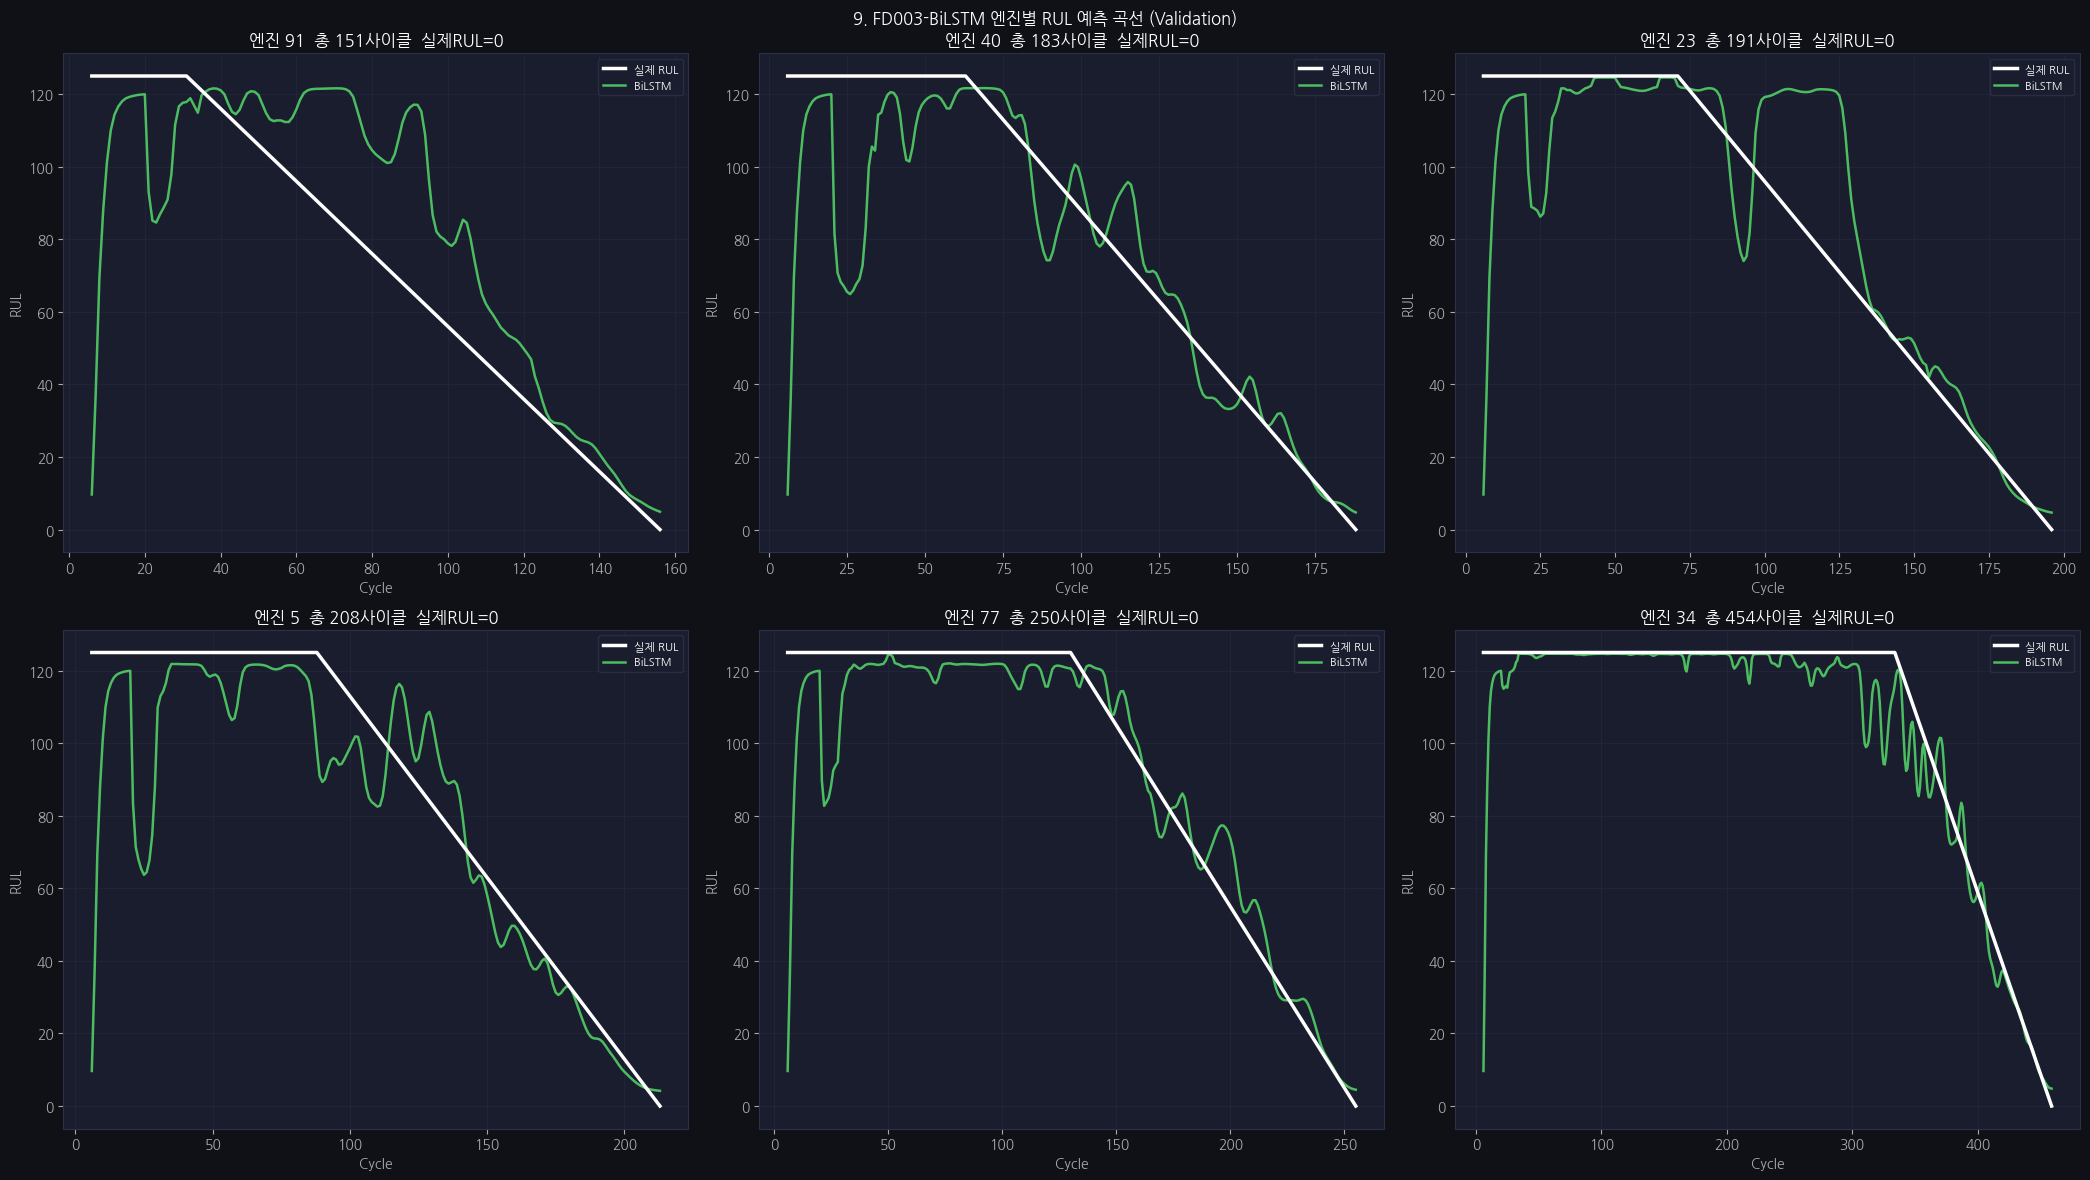

📊 RUL 곡선 저장: results_dl_fd003_bilstm/FD003_BiLSTM_rul_curves.png


In [13]:
print('=== 9. 엔진별 RUL 예측 곡선 ===')

# valid_ml: 시계열 전체 궤적이 있는 ML 데이터
valid_ml_local = pd.read_csv(os.path.join(DATA_DIR, f'{PREPROCESSING_PREFIX}_ml_valid.csv'))

val_lifecycles = valid_ml_local.groupby('unit_nr')['time_cycles'].max().sort_values()
n_sel      = min(6, len(val_lifecycles))
sel_units  = val_lifecycles.iloc[np.linspace(0, len(val_lifecycles)-1, n_sel, dtype=int)].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle(f'9. {DATASET_NAME}-{MODEL_NAME_STR} 엔진별 RUL 예측 곡선 (Validation)', fontweight='bold')

for ax, uid in zip(axes.flat, sel_units):
    udf      = valid_ml_local[valid_ml_local['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
    n        = len(udf)
    true_rul = udf['RUL'].values
    preds_all = []
    for t in range(n):
        start = max(0, t - WINDOW_SIZE + 1)
        feats_in = [c for c in DL_FEATURES if c in udf.columns]
        seg   = udf[feats_in].values[start:t+1].astype(np.float32)
        if len(seg) < WINDOW_SIZE:
            pad = np.zeros((WINDOW_SIZE - len(seg), N_FEATURES), np.float32)
            seg = np.vstack([pad, seg])
        preds_all.append(float(predict_np(BEST_MODEL, seg[np.newaxis])[0]))

    ax.plot(udf['time_cycles'], true_rul,  color='white',     lw=2.5, label='실제 RUL', zorder=5)
    ax.plot(udf['time_cycles'], preds_all, color=MODEL_COLOR, lw=1.8, alpha=0.9, label=MODEL_NAME_STR)
    ax.set_title(f'엔진 {uid}  총 {n}사이클  실제RUL={true_rul[-1]:.0f}')
    ax.set_xlabel('Cycle'); ax.set_ylabel('RUL')
    ax.legend(fontsize=8); ax.set_facecolor(BG2)

plt.tight_layout()
curve_path = os.path.join(RESULT_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_rul_curves.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'📊 RUL 곡선 저장: {curve_path}')


## 10. 모델 및 산출물 저장

In [14]:
print('=== 10. 모델 저장 ===')

state_path = os.path.join(MODEL_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_best.pt')
arch_path  = os.path.join(MODEL_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_arch.json')
torch.save(BEST_MODEL.state_dict(), state_path)
with open(arch_path, 'w') as f:
    json.dump(best_params, f, indent=2)

result_summary = {
    'dataset'        : DATASET_NAME,
    'model'          : MODEL_NAME_STR,
    'preprocessing'  : PREPROCESSING_PREFIX,
    'optimizer'      : OPTIMIZER_NAME,
    'scheduler'      : 'ReduceLROnPlateau' if USE_ADAMW else 'None',
    'params'         : best_params,
    'n_params'       : n_params,
    'n_trials'       : N_TRIALS,
    'val_eval_nasa'  : round(val_nasa_eval, 2),
    'val_eval_rmse'  : round(val_rmse_eval, 3),
    'test_rmse_off'  : round(test_rmse_off, 3),
    'test_nasa_off'  : round(test_nasa_off, 2),
    'test_mae'       : round(mean_absolute_error(test_targets, test_preds), 3),
    'test_r2'        : round(r2_score(test_targets, test_preds), 4),
    'fit_seconds'    : round(fit_time, 1),
    'eval_note'      : 'test_rmse/nasa: 엔진당 마지막 윈도우(is_last=True) 기준 공식 평가',
}
summary_path = os.path.join(RESULT_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_summary.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(result_summary, f, ensure_ascii=False, indent=2)

# 예측 결과 CSV (공식 평가 기준)
pred_csv_path = os.path.join(RESULT_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_test_pred.csv')
pd.DataFrame({
    'engine_id'    : range(1, len(test_targets)+1),
    'actual_rul'   : test_targets.astype(int),
    'predicted_rul': test_preds.round(2),
    'error'        : (test_preds - test_targets).round(2),
}).to_csv(pred_csv_path, index=False, encoding='utf-8-sig')

print(f'  모델 저장: {state_path}')
print(f'  요약 저장: {summary_path}')
print(f'  예측 CSV : {pred_csv_path}')
print(f'  평가 기준: 엔진당 마지막 윈도우 (is_last=True)')


=== 10. 모델 저장 ===
  모델 저장: models_dl_fd003_bilstm/FD003_BiLSTM_best.pt
  요약 저장: results_dl_fd003_bilstm/FD003_BiLSTM_summary.json
  예측 CSV : results_dl_fd003_bilstm/FD003_BiLSTM_test_pred.csv
  평가 기준: 엔진당 마지막 윈도우 (is_last=True)


## 11. 구글 드라이브 자동 저장

In [15]:
print('=== 11. 구글 드라이브 저장 ===')
import json as _json

BEST_DIR = '/content/drive/MyDrive/sparta_project/best_results'
os.makedirs(BEST_DIR, exist_ok=True)

drive_pred_path = os.path.join(BEST_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_pred.csv')
meta_path       = os.path.join(BEST_DIR, f'{DATASET_NAME}_{MODEL_NAME_STR}_best.json')

if os.path.exists(meta_path):
    with open(meta_path) as f:
        prev = _json.load(f)
    prev_rmse = prev.get('test_rmse_off', float('inf'))
else:
    prev_rmse = float('inf')

if test_rmse_off < prev_rmse:
    pd.DataFrame({
        'engine_id'    : range(1, len(test_targets)+1),
        'actual_rul'   : test_targets.astype(int),
        'predicted_rul': test_preds.round(2),
    }).to_csv(drive_pred_path, index=False, encoding='utf-8-sig')

    with open(meta_path, 'w') as f:
        _json.dump({
            'dataset'       : DATASET_NAME,
            'model'         : MODEL_NAME_STR,
            'preprocessing' : PREPROCESSING_PREFIX,
            'optimizer'     : OPTIMIZER_NAME,
            'test_rmse_off' : round(test_rmse_off, 4),
            'test_nasa_off' : round(test_nasa_off, 2),
            'val_eval_nasa' : round(val_nasa_eval, 2),
            'params'        : best_params,
            'eval_note'     : '엔진당 마지막 윈도우(is_last=True) 기준',
        }, f, ensure_ascii=False, indent=2)

    print(f'🏆 최고 성능 갱신! RMSE={test_rmse_off:.4f} → 드라이브 저장 완료')
    print(f'   저장 위치: {drive_pred_path}')
else:
    print(f'📊 현재 RMSE={test_rmse_off:.4f} | 기존 최고={prev_rmse:.4f} → 저장 안함')


=== 11. 구글 드라이브 저장 ===
🏆 최고 성능 갱신! RMSE=18.2275 → 드라이브 저장 완료
   저장 위치: /content/drive/MyDrive/sparta_project/best_results/FD003_BiLSTM_pred.csv


## 12. 최종 요약

In [16]:
print('='*70)
print(f' {DATASET_NAME}-{MODEL_NAME_STR} 실험 최종 요약')
print('='*70)
print(f'\n[실험 설정]')
print(f'  데이터셋  : {DATASET_NAME} (HPC + Fan 열화, 2가지 고장 모드, 단일 운전 조건)')
print(f'  모델      : {MODEL_NAME_STR} (양방향 BiLSTM — 순방향+역방향 동시 학습으로 열화 패턴 포착)')
print(f'  전처리    : {PREPROCESSING_PREFIX}')
print(f'  옵티마이저: {OPTIMIZER_NAME}')
print(f'  Scheduler : {"ReduceLROnPlateau" if USE_ADAMW else "없음"}')
print(f'  N_TRIALS  : {N_TRIALS}')
print(f'  파라미터 수: {n_params:,}')
print(f'\n[최적 하이퍼파라미터]')
for k,v in best_params.items():
    print(f'  {k:20s}: {v}')
print(f'\n[성능 결과]')
print(f'  Val NASA(eval)       : {val_nasa_eval:.2f}')
print(f'  Val RMSE(eval)       : {val_rmse_eval:.3f}')
print(f'  Test RMSE [공식]     : {test_rmse_off:.3f}  ← 엔진당 마지막 윈도우')
print(f'  Test NASA [공식]     : {test_nasa_off:.2f}')
print(f'  Test MAE             : {mean_absolute_error(test_targets, test_preds):.3f}')
print(f'  Test R²              : {r2_score(test_targets, test_preds):.4f}')
print(f'  학습 시간            : {fit_time:.1f}초')
print(f'\n[저장 파일]')
print(f'  모델   : {state_path}')
print(f'  요약   : {summary_path}')
print(f'  예측CSV: {pred_csv_path}')
print(f'  드라이브: {BEST_DIR}/{DATASET_NAME}_{MODEL_NAME_STR}_pred.csv')
print('='*70)


 FD003-BiLSTM 실험 최종 요약

[실험 설정]
  데이터셋  : FD003 (HPC + Fan 열화, 2가지 고장 모드, 단일 운전 조건)
  모델      : BiLSTM (양방향 BiLSTM — 순방향+역방향 동시 학습으로 열화 패턴 포착)
  전처리    : FD003_nc_cap125_sig2_win30
  옵티마이저: AdamW
  Scheduler : ReduceLROnPlateau
  N_TRIALS  : 30
  파라미터 수: 328,879

[최적 하이퍼파라미터]
  hidden_size         : 99
  num_layers          : 2
  dropout             : 0.159485507210749
  lr                  : 0.002803805018707268
  weight_decay        : 0.00901433674615103

[성능 결과]
  Val NASA(eval)       : 43.98
  Val RMSE(eval)       : 11.731
  Test RMSE [공식]     : 18.227  ← 엔진당 마지막 윈도우
  Test NASA [공식]     : 1451.92
  Test MAE             : 13.037
  Test R²              : 0.8061
  학습 시간            : 12.7초

[저장 파일]
  모델   : models_dl_fd003_bilstm/FD003_BiLSTM_best.pt
  요약   : results_dl_fd003_bilstm/FD003_BiLSTM_summary.json
  예측CSV: results_dl_fd003_bilstm/FD003_BiLSTM_test_pred.csv
  드라이브: /content/drive/MyDrive/sparta_project/best_results/FD003_BiLSTM_pred.csv
